## Phase 1: Dataset Exploration

### Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

### Step 2: Load Dataset

In [3]:
dataset_path = Path("../datasets/crop_recommendation/Crop_recommendation.csv")

print("Dataset Exists :", dataset_path.exists())

crop_df = pd.read_csv(dataset_path)

print("\nDataset Loaded Successfully")
print("Dataset Shape :", crop_df.shape)

Dataset Exists : True

Dataset Loaded Successfully
Dataset Shape : (2200, 8)


### Step 3: Dataset Overview

In [4]:
crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
print("Dataset Shape:", crop_df.shape)

Dataset Shape: (2200, 8)


In [6]:
print("Columns:")
print(crop_df.columns.tolist())

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [7]:
print("\nData Types:")
print(crop_df.dtypes)


Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


### Step 4: Check Missing & Duplicate Values

In [8]:
print("Missing Values\n")

print(crop_df.isnull().sum())

Missing Values

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [9]:
print("\nDuplicate Records :", crop_df.duplicated().sum())


Duplicate Records : 0


### Step 5: Explore Crop Classes

In [10]:
print("Number of Crop Classes :", crop_df["label"].nunique())

print("\nCrop Classes:\n")

print(sorted(crop_df["label"].unique()))

Number of Crop Classes : 22

Crop Classes:

['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [11]:
crop_counts = crop_df["label"].value_counts()

print(crop_counts)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


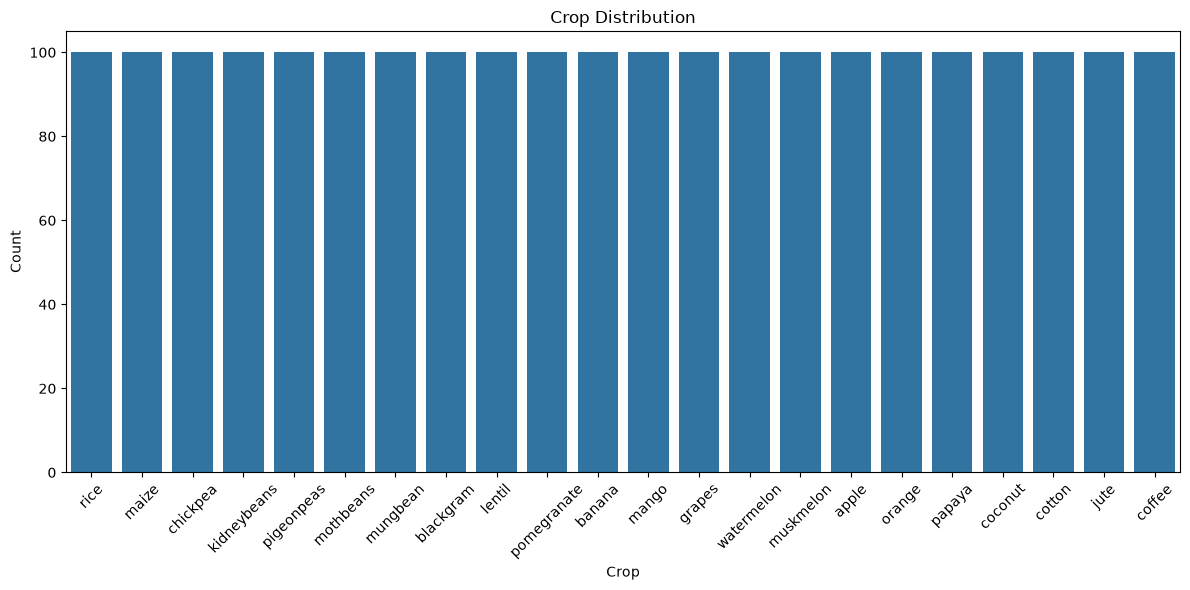

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=crop_df,
    x="label",
    order=crop_counts.index
)

plt.title("Crop Distribution")

plt.xlabel("Crop")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Step 6: Statistical Summary

In [13]:
crop_df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### Step 7: Correlation Analysis

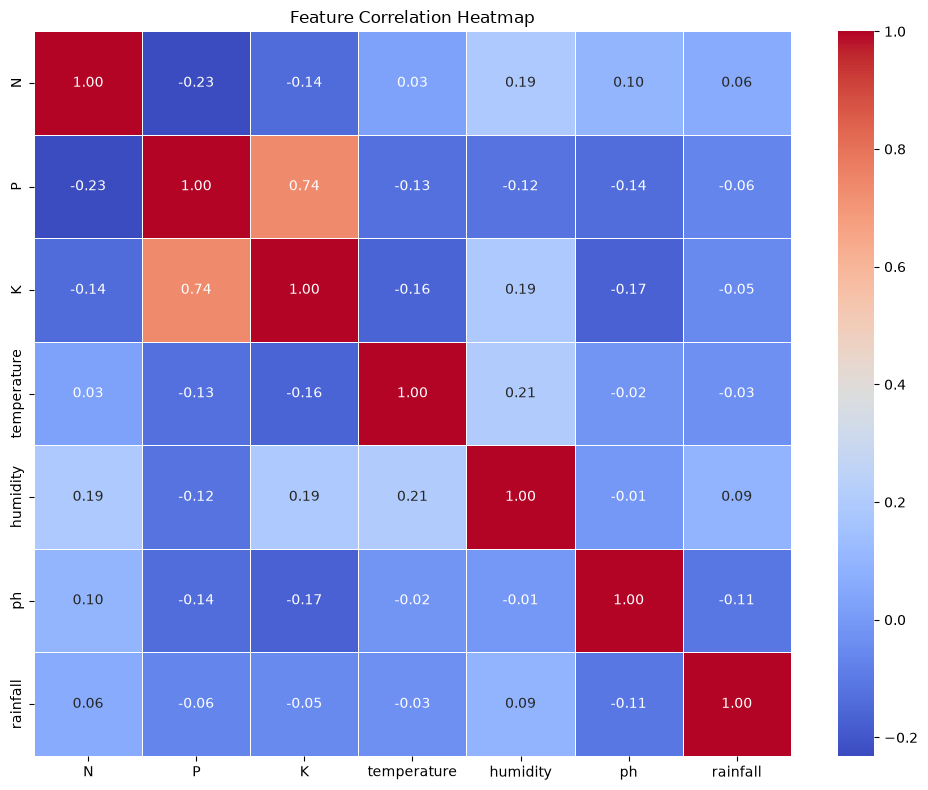

In [14]:
plt.figure(figsize=(10,8))

correlation_matrix = crop_df.drop(columns="label").corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

### Step 8: Feature Distribution

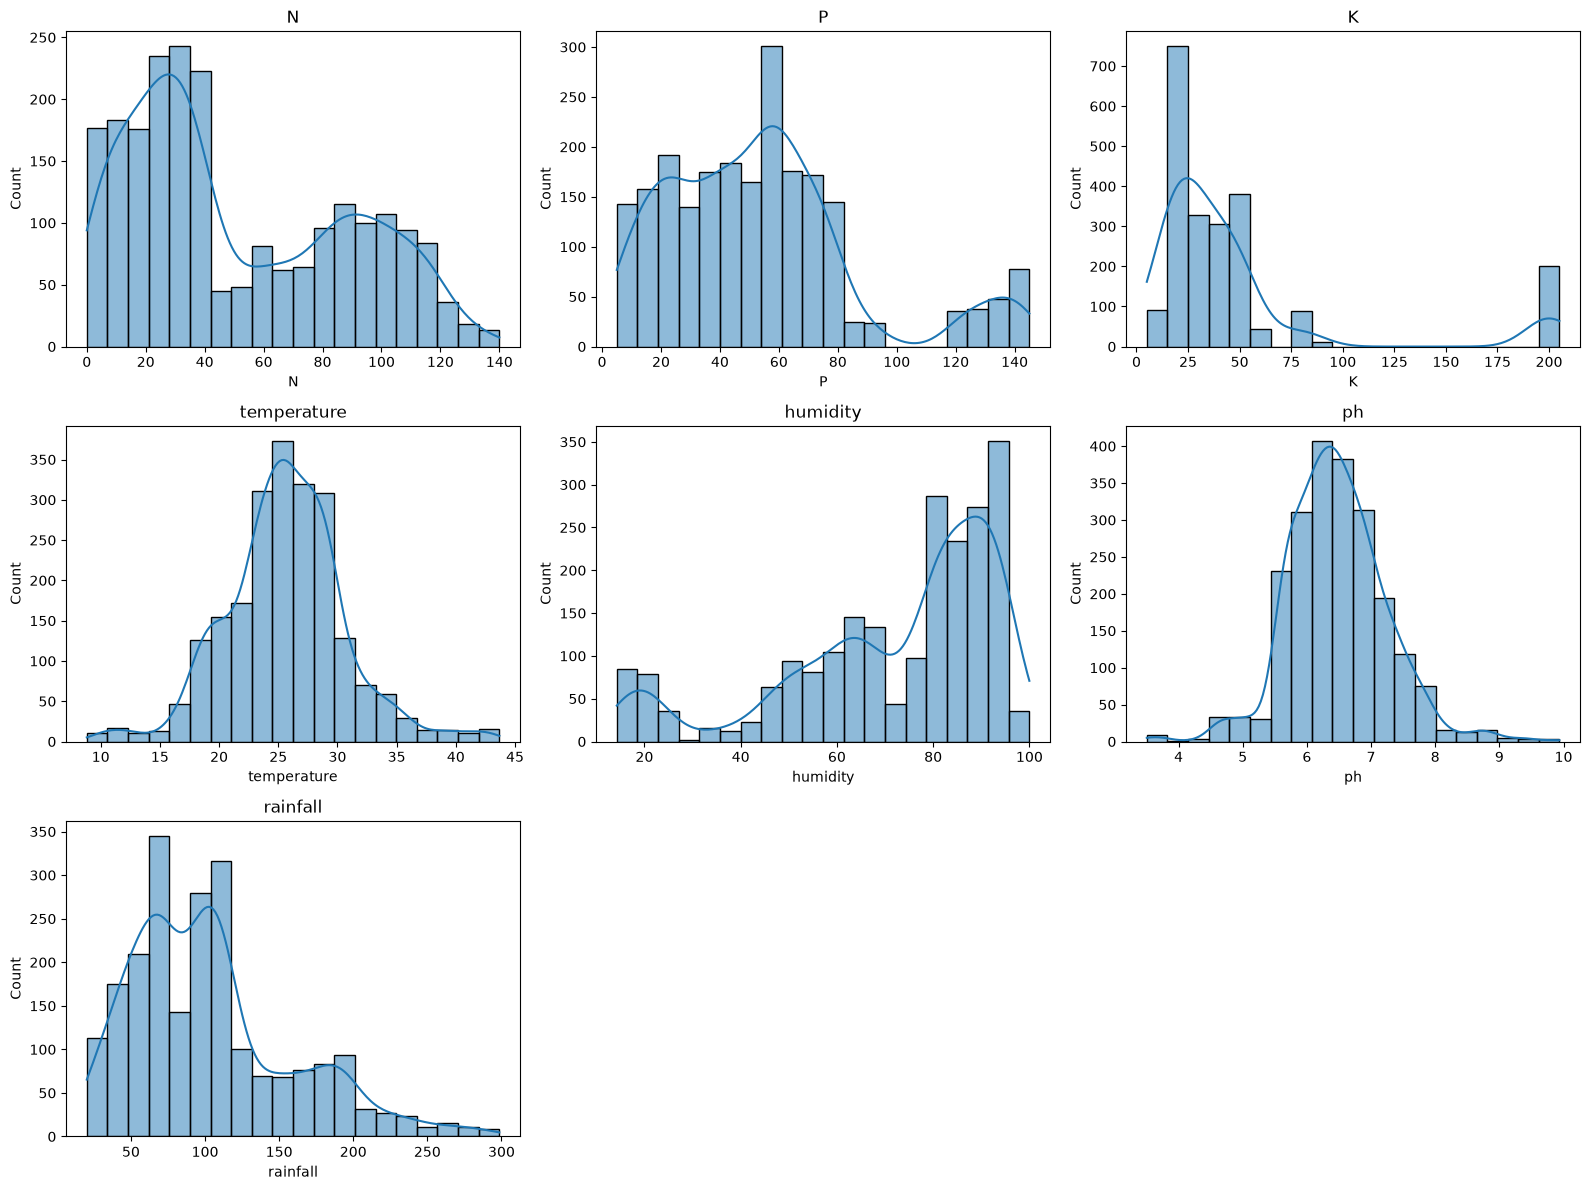

In [15]:
features = crop_df.drop(columns="label").columns

plt.figure(figsize=(16,12))

for i, feature in enumerate(features):

    plt.subplot(3,3,i+1)

    sns.histplot(
        crop_df[feature],
        bins=20,
        kde=True
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

## Phase 2: Data Preparation

### Step 9: Separate Features & Target

In [16]:
X = crop_df.drop(columns="label")

y = crop_df["label"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature Shape : (2200, 7)
Target Shape  : (2200,)

Features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


### Step 10: Encode Crop Labels

In [17]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

### Step 11: Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y_encoded

)

In [19]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1760, 7)
X_test : (440, 7)
y_train: (1760,)
y_test : (440,)


### Step 12: Feature Scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Phase 3: Model Selection & Development

### Step 13: Train Baseline Models

In [21]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    )

}

results = {}

print("Training Models...\n")

for name, model in models.items():

    # Use scaled data for Logistic Regression and KNN
    if name in ["Logistic Regression", "KNN"]:

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"{name:<22} Accuracy : {accuracy:.4f}")

Training Models...

Logistic Regression    Accuracy : 0.9727
Decision Tree          Accuracy : 0.9795
KNN                    Accuracy : 0.9795
Random Forest          Accuracy : 0.9955


### Step 14: Compare Model Performance

In [22]:
results_df = pd.DataFrame(

    results.items(),

    columns=["Model", "Accuracy"]

)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

results_df

,Model,Accuracy
0,Random Forest,0.995455
1,Decision Tree,0.979545
2,KNN,0.979545
3,Logistic Regression,0.972727


C:\Users\HP\AppData\Local\Temp\ipykernel_5180\3249580419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


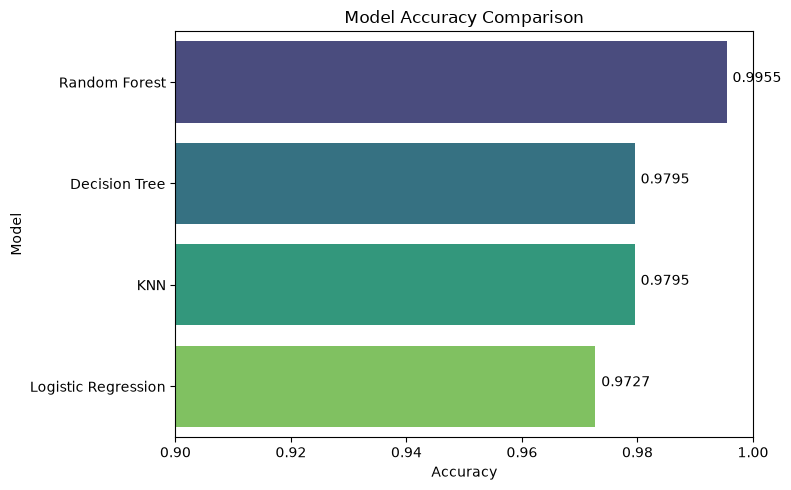

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0.90, 1.00)

for index, value in enumerate(results_df["Accuracy"]):
    plt.text(value + 0.001, index, f"{value:.4f}")

plt.tight_layout()

plt.show()

### Step 15: Hyperparameter Tuning

In [24]:
param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_m

In [25]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_ * 100)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Accuracy:
99.6022727272727


### Step 16: Train Final Optimized Model

In [26]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

## Phase 4: Model Evaluation

### Step 17: Evaluate Final Model

In [27]:
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Tuned Random Forest Test Accuracy:", test_accuracy * 100)

Tuned Random Forest Test Accuracy: 99.54545454545455


## Step 18: Generate Confusion Matrix

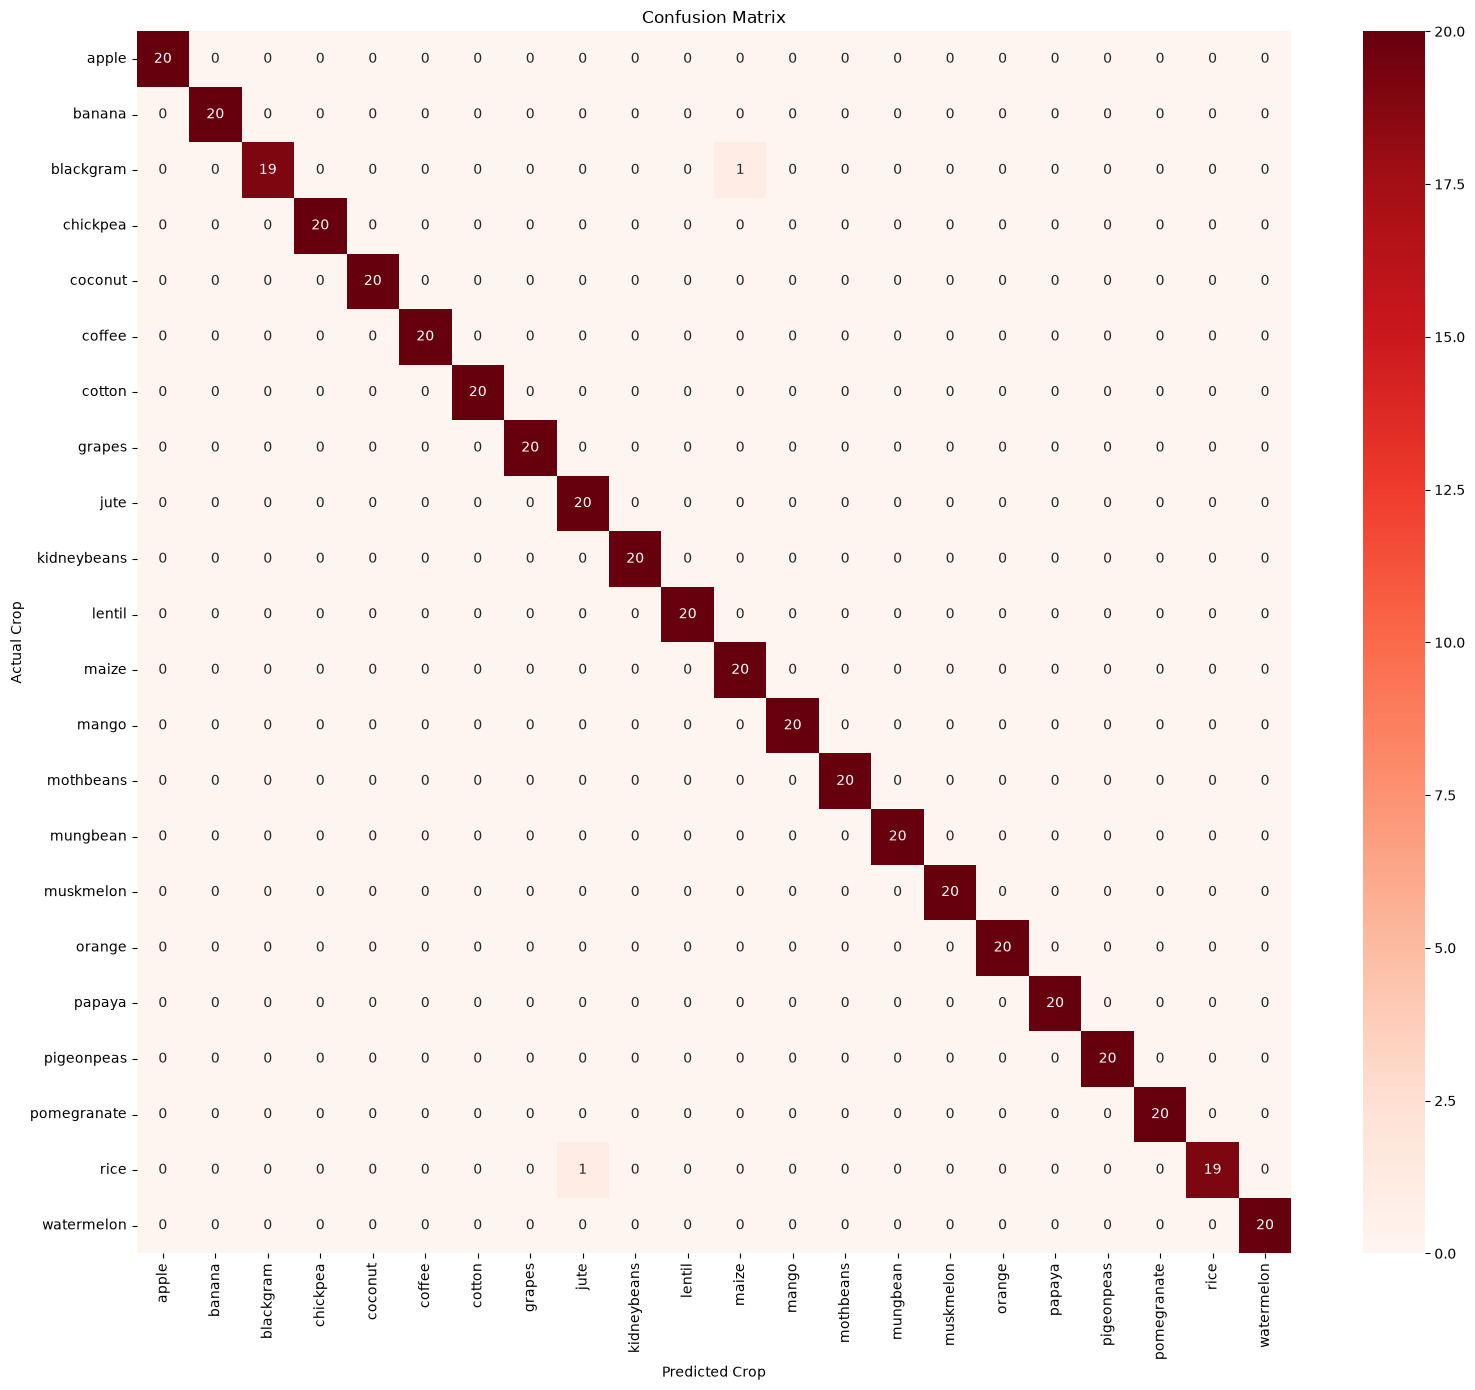

In [28]:
plt.figure(figsize=(16,14))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Step 19: Classification Report

In [29]:
print("Classification Report:")
print(classification_report(y_test,y_pred,
    target_names=label_encoder.classes_,digits=4
))

Classification Report:
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        20
      banana     1.0000    1.0000    1.0000        20
   blackgram     1.0000    0.9500    0.9744        20
    chickpea     1.0000    1.0000    1.0000        20
     coconut     1.0000    1.0000    1.0000        20
      coffee     1.0000    1.0000    1.0000        20
      cotton     1.0000    1.0000    1.0000        20
      grapes     1.0000    1.0000    1.0000        20
        jute     0.9524    1.0000    0.9756        20
 kidneybeans     1.0000    1.0000    1.0000        20
      lentil     1.0000    1.0000    1.0000        20
       maize     0.9524    1.0000    0.9756        20
       mango     1.0000    1.0000    1.0000        20
   mothbeans     1.0000    1.0000    1.0000        20
    mungbean     1.0000    1.0000    1.0000        20
   muskmelon     1.0000    1.0000    1.0000        20
      orange     1.0000    1.0000    1.0000        20
    

### Step 20: Feature Importance

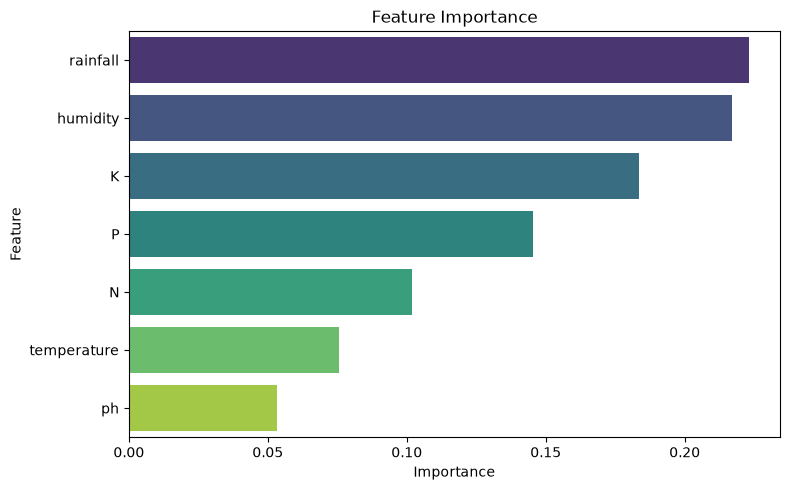

,Feature,Importance
6,rainfall,0.223133
4,humidity,0.216879
2,K,0.183446
1,P,0.145579
0,N,0.101962
3,temperature,0.075522
5,ph,0.053479


In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

feature_importance

## Phase 5: Model Saving & Deployment Preparation

### Step 21: Save Trained Model, StandardScaler, Label Encoder

In [31]:
from pathlib import Path

model_directory = Path("../models")

model_directory.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    model_directory / "crop_recommendation_model.pkl"
)

print("Crop Recommendation Model Saved Successfully")

Crop Recommendation Model Saved Successfully


In [32]:
joblib.dump(
    scaler,
    model_directory / "crop_scaler.pkl"
)

print("StandardScaler Saved Successfully")

StandardScaler Saved Successfully


In [33]:
joblib.dump(
    label_encoder,
    model_directory / "crop_label_encoder.pkl"
)

print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully


### Step 22: Test Prediction Function

In [34]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data = pd.DataFrame([{
        "N": N,
        "P": P,
        "K": K,
        "temperature": temperature,
        "humidity": humidity,
        "ph": ph,
        "rainfall": rainfall }])

    prediction = best_model.predict(input_data)

    crop_name = label_encoder.inverse_transform(prediction)[0]

    return crop_name

In [35]:
result = predict_crop(
    N=90,
    P=42,
    K=43,
    temperature=20.9,
    humidity=82,
    ph=6.5,
    rainfall=202
)

print("Recommended Crop:", result)

Recommended Crop: rice
